# JFK 발(發) 택시 수요 기반 신규 버스 노선 후보 분석

**목표:** JFK 공항에서 출발하는 택시 수요 데이터, 기존 버스 노선 커버리지, 지하철 커버리지를
함께 놓고, 대중교통(버스+지하철 모두) 사각지대이면서 택시 수요가 높은 지역을 찾아
신규 버스 노선 후보지를 제안한다.

**데이터 전제:**
- `jfk_zone_stats.csv`: pickup=JFK Airport로 고정된 트립들의 dropoff(zone)별 집계
- `route_zone_coverage.json`: JFK 접근 버스 노선 8개의 zone별 커버리지
- `subway_zone_coverage.csv`: zone별 지하철역 존재 여부 및 역 개수
- `taxi_zones.geojson`: TLC 공식 zone 경계 (지도 시각화용)


In [1]:
import json
import platform
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

sns.set_style("whitegrid")

# ---- 한글 폰트 설정 (sns.set_style 이후에 적용해야 덮어써지지 않음) ----
system_name = platform.system()
if system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False


## 1. 경로 설정 (config)

파일 위치가 바뀌면 이 셀만 수정하면 됩니다.

In [2]:
BUS_ROUTES_PATH = "../output/bus_data/route_zone_coverage.json"
TAXI_STATS_PATH = "../output/jfk_zone_stats/jfk_zone_stats.csv"
SUBWAY_PATH = "../output/subway_data/subway_zone_coverage.csv"
ZONES_GEOJSON_PATH = "../data/taxi_zones.geojson"

JFK_LOCATION_ID = 132  # TLC 공식 zone ID 기준


## 2. 데이터 로드

In [3]:
with open(BUS_ROUTES_PATH, "r", encoding="utf-8") as f:
    bus_routes = json.load(f)

taxi_df = pd.read_csv(TAXI_STATS_PATH)
subway_df = pd.read_csv(SUBWAY_PATH)

print(f"버스 노선 수: {len(bus_routes)}")
print(f"택시 존 수: {taxi_df.shape[0]}")
print(f"지하철 데이터 존 수: {subway_df.shape[0]}")
taxi_df.head()


버스 노선 수: 8
택시 존 수: 261
지하철 데이터 존 수: 265


,do_location_id,zone,borough,trip_count,avg_distance_mi,total_distance_mi,avg_fare,total_fare,fare_median
0,265,Outside of NYC,NaN,354243,29.729668,1.053153e+07,122.958378,43557144.77,111.90
1,230,Times Sq/Theatre District,Manhattan,67707,18.041472,1.221534e+06,87.399837,5917580.77,74.92
2,132,JFK Airport,Queens,49410,3.017214,1.490806e+05,26.481294,1308440.75,16.21
3,164,Midtown South,Manhattan,40269,17.294012,6.964126e+05,83.240878,3352026.92,70.43
4,216,South Ozone Park,Queens,39092,3.381641,1.321951e+05,17.553396,686197.35,16.70


## 3. 버스 노선 커버리지 추출

노선마다 중첩된 `covered_zones` 리스트를 순회하며, 어떤 zone을 지나는 노선이 몇 개인지 집계합니다.

In [4]:
covered_location_ids = set()
zone_route_count = {}

for route in bus_routes:
    for z in route["covered_zones"]:
        loc_id = z["location_id"]
        covered_location_ids.add(loc_id)
        zone_route_count[loc_id] = zone_route_count.get(loc_id, 0) + 1

print(f"버스가 커버하는 고유 zone 개수: {len(covered_location_ids)}")


버스가 커버하는 고유 zone 개수: 27


## 4. 지하철 커버리지 병합

버스와 마찬가지로, 이 zone에 지하철역이 있는지(`has_subway`)와 역 개수(`station_count`)를 결합합니다.

In [5]:
taxi_df["has_bus_route"] = taxi_df["do_location_id"].isin(covered_location_ids)
taxi_df["bus_route_count"] = taxi_df["do_location_id"].map(zone_route_count).fillna(0).astype(int)

subway_lookup = subway_df.set_index("location_id")[["has_subway", "station_count"]]
taxi_df = taxi_df.merge(subway_lookup, left_on="do_location_id", right_index=True, how="left")

# subway_zone_coverage.csv에 없는 zone은 지하철 정보가 없다는 뜻 -> False/0으로 채움
taxi_df["has_subway"] = taxi_df["has_subway"].fillna(False)
taxi_df["station_count"] = taxi_df["station_count"].fillna(0).astype(int)

taxi_df[["zone","borough","trip_count","has_bus_route","has_subway","station_count"]].head(10)


,zone,borough,trip_count,has_bus_route,has_subway,station_count
0,Outside of NYC,NaN,354243,False,False,0
1,Times Sq/Theatre District,Manhattan,67707,False,True,6
2,JFK Airport,Queens,49410,True,True,1
3,Midtown South,Manhattan,40269,False,True,3
4,South Ozone Park,Queens,39092,True,True,4
5,Baisley Park,Queens,33933,True,False,0
6,Clinton East,Manhattan,33924,False,True,1
7,Midtown North,Manhattan,28259,False,True,2
8,East Chelsea,Manhattan,27396,False,True,1
9,Williamsburg (North Side),Brooklyn,27181,False,True,1


## 5. 대중교통 상태 4단계 분류

버스와 지하철 여부를 조합해 zone을 4가지로 분류합니다.
**우리가 진짜 찾아야 할 건 "대중교통 사각지대"(버스도 지하철도 없음) 이면서 택시 수요가 높은 곳**입니다.

In [6]:
def classify_transit(row):
    if row["has_bus_route"] and row["has_subway"]:
        return "버스+지하철 모두 있음"
    elif row["has_bus_route"]:
        return "버스만 있음"
    elif row["has_subway"]:
        return "지하철만 있음"
    else:
        return "대중교통 사각지대"

taxi_df["transit_status"] = taxi_df.apply(classify_transit, axis=1)

status_summary = taxi_df.groupby("transit_status").agg(
    zone_count=("zone", "count"),
    total_trips=("trip_count", "sum"),
    avg_fare=("avg_fare", "mean")
).sort_values("total_trips", ascending=False)

status_summary


,zone_count,total_trips,avg_fare
transit_status,,,
지하철만 있음,148,1330338,73.097034
대중교통 사각지대,85,612594,67.333936
버스+지하철 모두 있음,17,251102,32.448126
버스만 있음,10,116521,26.502081


## 6. 신규 노선 후보 추출: 대중교통 사각지대 상위 zone

버스도 지하철도 없는 zone 중, JFK 발 택시 수요가 가장 높은 곳부터 정렬합니다.
`Outside of NYC`, `N/A` 같은 실제 지역이 아닌 값은 제외합니다.

In [7]:
top_n = 15
desert = taxi_df[taxi_df["transit_status"] == "대중교통 사각지대"].sort_values("trip_count", ascending=False)
desert_clean = desert[~desert["zone"].isin(["Outside of NYC", "N/A"])].head(top_n)

print("=== JFK 발 택시 수요는 있지만 버스도 지하철도 없는 상위 목적지 ===")
desert_clean[["zone","borough","trip_count","avg_distance_mi","avg_fare"]]


=== JFK 발 택시 수요는 있지만 버스도 지하철도 없는 상위 목적지 ===


,zone,borough,trip_count,avg_distance_mi,avg_fare
15,LaGuardia Airport,Queens,24086,11.600084,50.995179
31,UN/Turtle Bay South,Manhattan,17149,17.053330,75.556341
58,Yorkville East,Manhattan,12231,18.952981,74.470897
63,Lenox Hill East,Manhattan,11198,18.650072,74.797048
71,Kips Bay,Manhattan,9640,17.258700,69.319291
74,Clinton West,Manhattan,9375,19.518410,84.102810
76,Battery Park City,Manhattan,9125,23.936799,96.290792
80,Laurelton,Queens,8773,5.545599,23.793064
85,Meatpacking/West Village West,Manhattan,8317,20.483957,97.435201
95,Stuy Town/Peter Cooper Village,Manhattan,7212,18.171306,72.807220


## 7. 시각화: 대중교통 사각지대 막대그래프

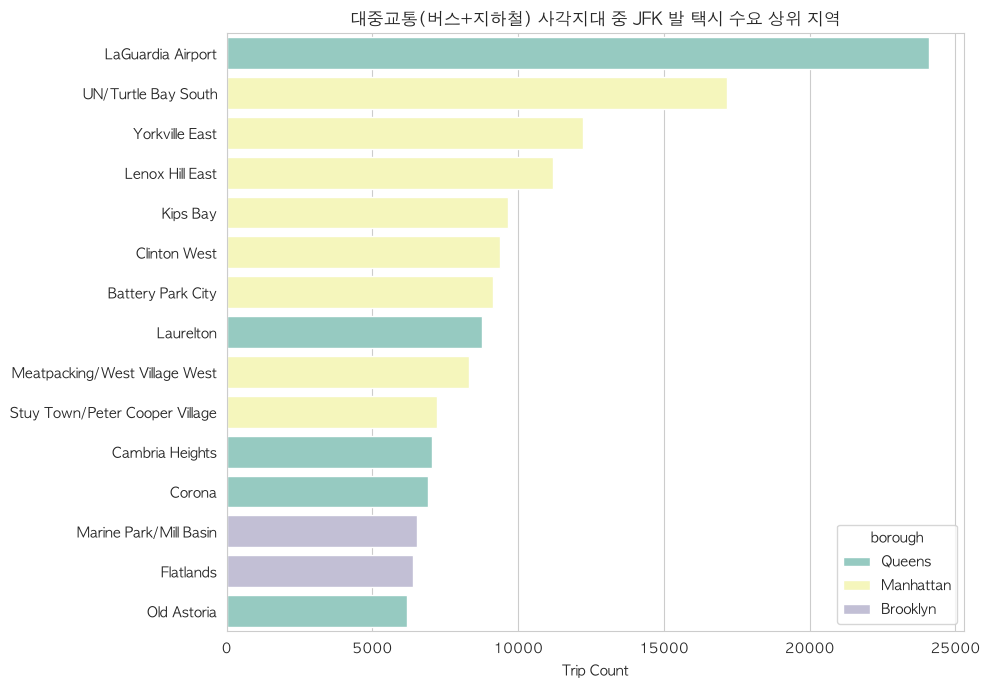

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=desert_clean, y="zone", x="trip_count", hue="borough", dodge=False, ax=ax)
ax.set_title("대중교통(버스+지하철) 사각지대 중 JFK 발 택시 수요 상위 지역")
ax.set_xlabel("Trip Count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 8. 자치구별 대중교통 상태 비교

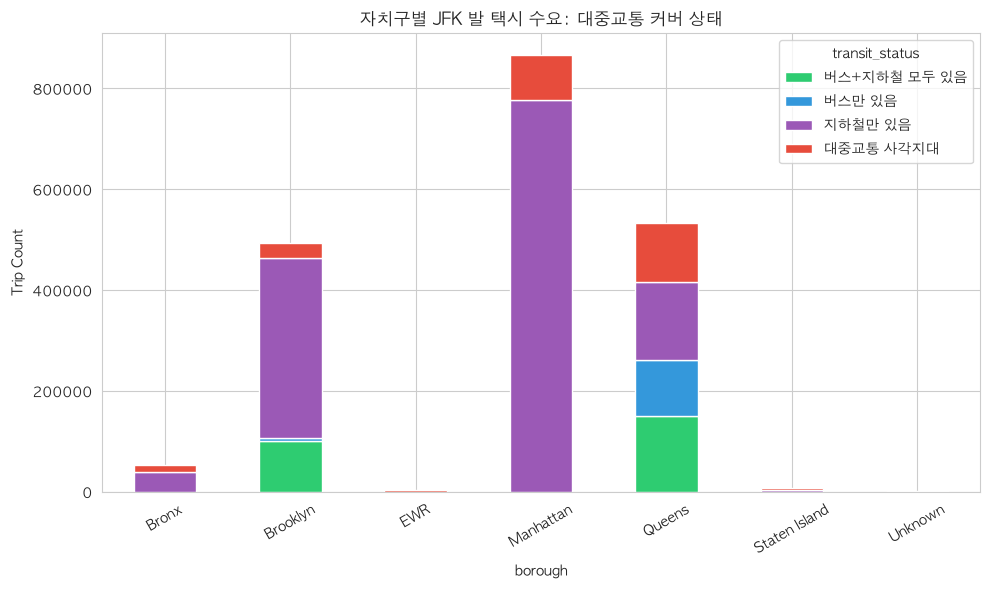

In [9]:
borough_status = (
    taxi_df.groupby(["borough", "transit_status"])["trip_count"]
    .sum()
    .unstack(fill_value=0)
)

status_order = ["버스+지하철 모두 있음", "버스만 있음", "지하철만 있음", "대중교통 사각지대"]
status_order = [c for c in status_order if c in borough_status.columns]
borough_status = borough_status[status_order]

fig, ax = plt.subplots(figsize=(10, 6))
borough_status.plot(
    kind="bar", stacked=True, ax=ax,
    color=["#2ecc71", "#3498db", "#9b59b6", "#e74c3c"][:len(status_order)]
)
ax.set_title("자치구별 JFK 발 택시 수요: 대중교통 커버 상태")
ax.set_ylabel("Trip Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 9. 지도 시각화: JFK 출발지 + 버스 노선(선) + 대중교통 상태(배경색) + 택시 수요(원)

TLC 공식 zone 경계(shapefile/geojson)를 불러와 좌표계를 평면 좌표계(EPSG:2263, feet)로 변환합니다.
위경도 상태로 centroid나 거리를 계산하면 왜곡이 생기기 때문입니다.

In [10]:
zones_gdf = gpd.read_file(ZONES_GEOJSON_PATH)

# 실제 컬럼명이 다를 수 있어 방어적으로 통일
id_col_candidates = ["LocationID", "location_id", "locationid"]
id_col = next((c for c in id_col_candidates if c in zones_gdf.columns), None)
if id_col is None:
    raise ValueError(f"LocationID 관련 컬럼을 못 찾았습니다. 실제 컬럼: {zones_gdf.columns.tolist()}")

zones_gdf = zones_gdf.rename(columns={id_col: "LocationID"})
zones_gdf["LocationID"] = zones_gdf["LocationID"].astype(int)

if zones_gdf.crs is None:
    zones_gdf = zones_gdf.set_crs("EPSG:4326")
zones_gdf = zones_gdf.to_crs(epsg=2263)

merged_gdf = zones_gdf.merge(taxi_df, left_on="LocationID", right_on="do_location_id", how="left")
merged_gdf["trip_count"] = merged_gdf["trip_count"].fillna(0)
merged_gdf["transit_status"] = merged_gdf["transit_status"].fillna("대중교통 사각지대")
merged_gdf["station_count"] = merged_gdf["station_count"].fillna(0)
merged_gdf["centroid"] = merged_gdf.geometry.centroid

print(f"매칭된 zone 수: {merged_gdf['do_location_id'].notna().sum()} / {len(merged_gdf)}")


매칭된 zone 수: 258 / 263


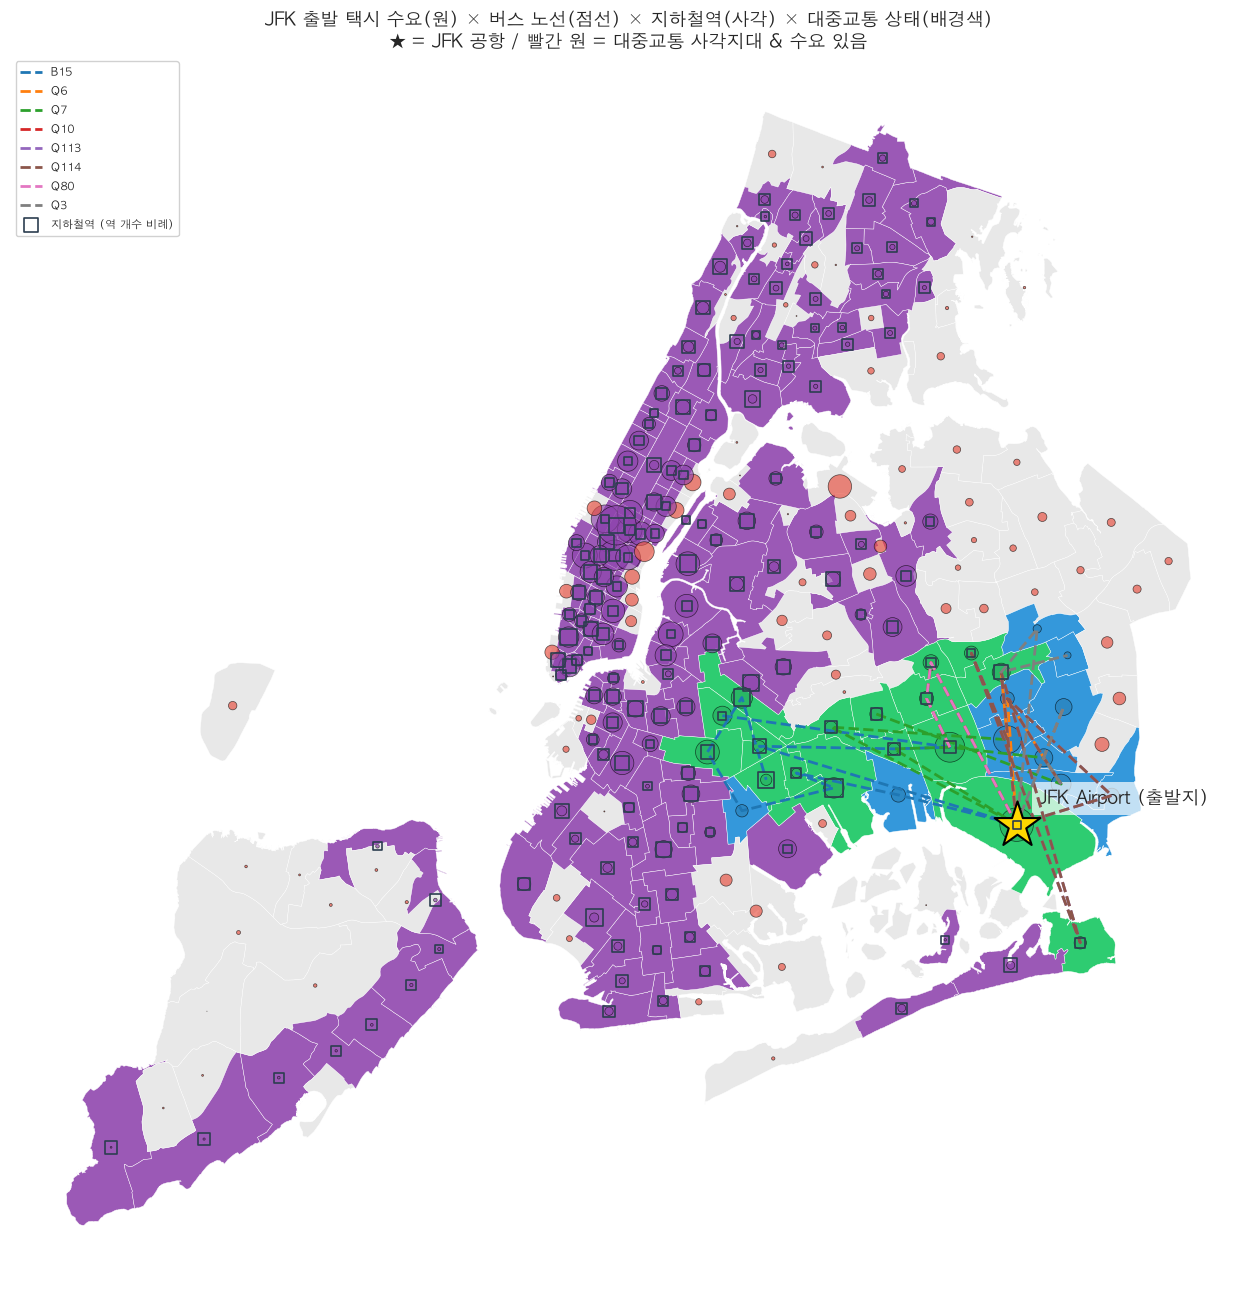

In [11]:
status_colors = {
    "버스+지하철 모두 있음": "#2ecc71",
    "버스만 있음": "#3498db",
    "지하철만 있음": "#9b59b6",
    "대중교통 사각지대": "#e8e8e8",
}
demand_point_colors = {
    "버스+지하철 모두 있음": "#27ae60",
    "버스만 있음": "#2980b9",
    "지하철만 있음": "#8e44ad",
    "대중교통 사각지대": "#e74c3c",
}

fig, ax = plt.subplots(figsize=(13, 13))

# ① 배경: 대중교통 상태별 zone 색칠
merged_gdf.plot(
    ax=ax,
    color=merged_gdf["transit_status"].map(status_colors),
    edgecolor="white", linewidth=0.3
)

# ② 택시 수요 버블 (원 크기 = trip_count, 색 = 대중교통 상태)
demand_zones = merged_gdf[merged_gdf["trip_count"] > 0].copy()
sizes = (demand_zones["trip_count"] / demand_zones["trip_count"].max()) * 800

ax.scatter(
    demand_zones.centroid.x, demand_zones.centroid.y,
    s=sizes,
    c=demand_zones["transit_status"].map(demand_point_colors),
    alpha=0.65, edgecolor="black", linewidth=0.5, zorder=3
)

# ③ 출발지(JFK) 강조 — 노란 별
jfk_row = merged_gdf[merged_gdf["LocationID"] == JFK_LOCATION_ID]
if not jfk_row.empty:
    jfk_x, jfk_y = jfk_row.centroid.x.values[0], jfk_row.centroid.y.values[0]
    ax.scatter(
        jfk_x, jfk_y, marker="*", s=1200, c="gold",
        edgecolor="black", linewidth=1.5, zorder=5
    )
    ax.annotate(
        "JFK Airport (출발지)", (jfk_x, jfk_y),
        textcoords="offset points", xytext=(15, 15), fontsize=13,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )
else:
    print("경고: JFK Airport(LocationID=132)를 못 찾았습니다. merged_gdf의 LocationID를 확인하세요.")

# ④ 버스 노선을 선으로 표시 (노선별 다른 색 점선)
route_colors = plt.get_cmap("tab10")
for i, route in enumerate(bus_routes):
    loc_ids = [z["location_id"] for z in route["covered_zones"]]
    route_zones = merged_gdf[merged_gdf["LocationID"].isin(loc_ids)]
    if len(route_zones) >= 2:
        line = LineString(list(zip(route_zones.centroid.x, route_zones.centroid.y)))
        gpd.GeoSeries([line], crs=merged_gdf.crs).plot(
            ax=ax, color=route_colors(i % 10), linewidth=2,
            linestyle="--", label=route["route_name"], zorder=4
        )

# ⑤ 지하철역 표시 (역 개수에 비례한 크기의 사각 테두리 마커)
subway_zones = merged_gdf[merged_gdf["station_count"] > 0]
ax.scatter(
    subway_zones.centroid.x, subway_zones.centroid.y,
    marker="s", s=subway_zones["station_count"] * 15 + 20,
    c="none", edgecolor="#2c3e50", linewidth=1.2, zorder=6,
    label="지하철역 (역 개수 비례)"
)

ax.set_title(
    "JFK 출발 택시 수요(원) × 버스 노선(점선) × 지하철역(사각) × 대중교통 상태(배경색)\n"
    "★ = JFK 공항 / 빨간 원 = 대중교통 사각지대 & 수요 있음",
    fontsize=13
)
ax.set_axis_off()
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig("../output/jfk_transit_gap_map.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. 최종 신규 노선 후보 요약

In [12]:
candidates = desert_clean.copy()
candidates["demand_rank"] = range(1, len(candidates) + 1)
candidates_display = candidates[["demand_rank", "zone", "borough", "trip_count", "avg_fare", "bus_route_count"]].reset_index(drop=True)

print("=== 신규 버스 노선 검토 후보 (대중교통 사각지대 + 수요 기준 상위) ===")
display(candidates_display)

top3 = candidates_display.head(3)
print("\n우선 검토 대상 3곳:")
for _, row in top3.iterrows():
    print(f"- {row['zone']} ({row['borough']}): 연 {row['trip_count']:,}건, 평균요금 ${row['avg_fare']:.2f}, 기존 버스 노선 {row['bus_route_count']}개")

print("""
※ 해석 시 주의사항:
1. 이 데이터는 pickup=JFK Airport로 고정된 트립들의 dropoff 분포이므로,
   아래 후보들은 'JFK ↔ 특정 zone' 신규 노선 후보입니다.
2. 사용된 버스 데이터는 JFK 접근 노선 8개뿐이므로, 이 8개 노선 대비 갭 분석입니다.
3. 지하철 커버리지를 함께 고려해, 버스도 지하철도 없는 '순수 사각지대'만 후보로 추렸습니다.
4. covered_zones 리스트 순서가 실제 도로 경로 순서라는 보장이 없어, 지도의 버스 노선 선은 근사 표현입니다.
5. 실제 노선 설계에는 정확한 도로망 및 GTFS shapes.txt 데이터가 추가로 필요합니다.
""")


=== 신규 버스 노선 검토 후보 (대중교통 사각지대 + 수요 기준 상위) ===


,demand_rank,zone,borough,trip_count,avg_fare,bus_route_count
0,1,LaGuardia Airport,Queens,24086,50.995179,0
1,2,UN/Turtle Bay South,Manhattan,17149,75.556341,0
2,3,Yorkville East,Manhattan,12231,74.470897,0
3,4,Lenox Hill East,Manhattan,11198,74.797048,0
4,5,Kips Bay,Manhattan,9640,69.319291,0
5,6,Clinton West,Manhattan,9375,84.102810,0
6,7,Battery Park City,Manhattan,9125,96.290792,0
7,8,Laurelton,Queens,8773,23.793064,0
8,9,Meatpacking/West Village West,Manhattan,8317,97.435201,0
9,10,Stuy Town/Peter Cooper Village,Manhattan,7212,72.807220,0



우선 검토 대상 3곳:
- LaGuardia Airport (Queens): 연 24,086건, 평균요금 $51.00, 기존 버스 노선 0개
- UN/Turtle Bay South (Manhattan): 연 17,149건, 평균요금 $75.56, 기존 버스 노선 0개
- Yorkville East (Manhattan): 연 12,231건, 평균요금 $74.47, 기존 버스 노선 0개

※ 해석 시 주의사항:
1. 이 데이터는 pickup=JFK Airport로 고정된 트립들의 dropoff 분포이므로,
   아래 후보들은 'JFK ↔ 특정 zone' 신규 노선 후보입니다.
2. 사용된 버스 데이터는 JFK 접근 노선 8개뿐이므로, 이 8개 노선 대비 갭 분석입니다.
3. 지하철 커버리지를 함께 고려해, 버스도 지하철도 없는 '순수 사각지대'만 후보로 추렸습니다.
4. covered_zones 리스트 순서가 실제 도로 경로 순서라는 보장이 없어, 지도의 버스 노선 선은 근사 표현입니다.
5. 실제 노선 설계에는 정확한 도로망 및 GTFS shapes.txt 데이터가 추가로 필요합니다.

